# Домашнее задание: многослойная нейронная сеть для Fashion MNIST

Цель работы: построить модель на основе полносвязных слоев для классификации изображений Fashion MNIST и получить точность на тестовой выборке строго выше 88%.

В решении используется только MLP: сверточные слои, предобученные модели и transfer learning не применяются.

## 1. Импорт библиотек

Импортируем необходимые библиотеки, фиксируем случайные состояния и автоматически выбираем устройство для вычислений.

In [1]:
import random
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import torch
from torch import nn
from torch.utils.data import DataLoader, random_split
from torchvision import datasets, transforms

SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Используемое устройство: {device}')

Используемое устройство: cpu


## 2. Загрузка и подготовка данных

Загрузим Fashion MNIST из `torchvision.datasets`, преобразуем изображения в тензоры и нормализуем их статистиками, подходящими для этого датасета.

Исходную обучающую выборку разделим на train и validation в пропорции 90% / 10%.

In [2]:
FASHION_MNIST_MEAN = 0.2860
FASHION_MNIST_STD = 0.3530

transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((FASHION_MNIST_MEAN,), (FASHION_MNIST_STD,)),
])

data_dir = Path('data')

full_train_dataset = datasets.FashionMNIST(
    root=str(data_dir),
    train=True,
    download=True,
    transform=transform,
)

test_dataset = datasets.FashionMNIST(
    root=str(data_dir),
    train=False,
    download=True,
    transform=transform,
)

train_size = int(0.9 * len(full_train_dataset))
validation_size = len(full_train_dataset) - train_size

split_generator = torch.Generator().manual_seed(SEED)
train_dataset, validation_dataset = random_split(
    full_train_dataset,
    [train_size, validation_size],
    generator=split_generator,
)

BATCH_SIZE = 128
NUM_WORKERS = 0
PIN_MEMORY = device.type == 'cuda'

loader_generator = torch.Generator().manual_seed(SEED)

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
    generator=loader_generator,
)

validation_loader = DataLoader(
    validation_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=NUM_WORKERS,
    pin_memory=PIN_MEMORY,
)

print(f'Размер исходной обучающей выборки: {len(full_train_dataset)}')
print(f'Размер train: {len(train_dataset)}')
print(f'Размер validation: {len(validation_dataset)}')
print(f'Размер test: {len(test_dataset)}')

100%|██████████| 26.4M/26.4M [00:02<00:00, 13.1MB/s]
100%|██████████| 29.5k/29.5k [00:00<?, ?B/s]
100%|██████████| 4.42M/4.42M [00:00<00:00, 35.9MB/s]
100%|██████████| 5.15k/5.15k [00:00<?, ?B/s]

Размер исходной обучающей выборки: 60000
Размер train: 54000
Размер validation: 6000
Размер test: 10000


## 3. Просмотр данных

Посмотрим несколько изображений из обучающей выборки вместе с названиями классов.

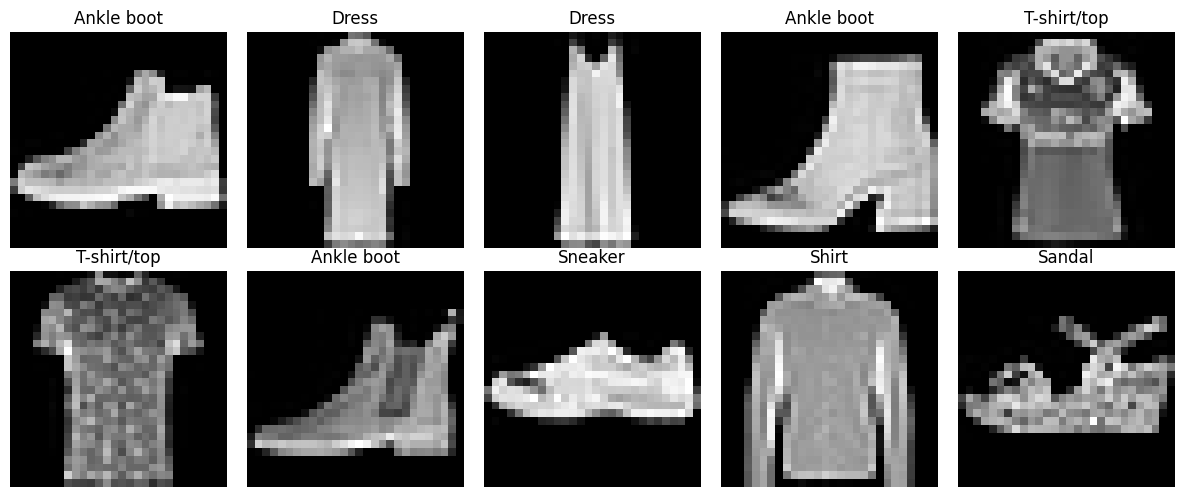

In [3]:
class_names = [
    'T-shirt/top',
    'Trouser',
    'Pullover',
    'Dress',
    'Coat',
    'Sandal',
    'Shirt',
    'Sneaker',
    'Bag',
    'Ankle boot',
]

images, labels = next(iter(train_loader))

plt.figure(figsize=(12, 5))
for index in range(10):
    plt.subplot(2, 5, index + 1)

    # Возвращаем изображение из нормализованного масштаба к диапазону [0, 1].
    image = images[index].squeeze().cpu().numpy()
    image = image * FASHION_MNIST_STD + FASHION_MNIST_MEAN
    image = np.clip(image, 0, 1)

    plt.imshow(image, cmap='gray')
    plt.title(class_names[labels[index].item()])
    plt.axis('off')

plt.tight_layout()
plt.show()

## 4. Стартовая архитектура

Модель состоит только из полносвязных слоев. Перед ними изображение размера 28 × 28 преобразуется в вектор из 784 признаков с помощью `nn.Flatten()`.

В последнем слое нет `Softmax`, потому что для обучения используется `nn.CrossEntropyLoss`, которая ожидает логиты.

In [4]:
class FashionMNISTMLP(nn.Module):
    def __init__(self):
        super().__init__()

        self.network = nn.Sequential(
            nn.Flatten(),
            nn.Linear(28 * 28, 1024),
            nn.ReLU(),
            nn.Dropout(p=0.20),
            nn.Linear(1024, 512),
            nn.ReLU(),
            nn.Dropout(p=0.20),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.Dropout(p=0.10),
            nn.Linear(256, 10),
        )

    def forward(self, x):
        return self.network(x)


def count_trainable_parameters(model):
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


model = FashionMNISTMLP().to(device)

print(model)
print(f'Обучаемых параметров: {count_trainable_parameters(model):,}'.replace(',', ' '))

FashionMNISTMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=512, out_features=256, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.1, inplace=False)
    (10): Linear(in_features=256, out_features=10, bias=True)
  )
)
Обучаемых параметров: 1 462 538


## 5. Обучение

Реализуем отдельные функции для одной эпохи обучения и оценки качества. Для выбора лучшей модели используем validation accuracy. Тестовая выборка не используется при подборе параметров.

In [5]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    model.train()

    total_loss = 0.0
    correct_predictions = 0
    total_objects = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        optimizer.zero_grad()
        logits = model(images)
        loss = criterion(logits, labels)
        loss.backward()
        optimizer.step()

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        correct_predictions += (logits.argmax(dim=1) == labels).sum().item()
        total_objects += batch_size

    average_loss = total_loss / total_objects
    accuracy = correct_predictions / total_objects
    return average_loss, accuracy


@torch.no_grad()
def evaluate(model, dataloader, criterion, device):
    model.eval()

    total_loss = 0.0
    correct_predictions = 0
    total_objects = 0

    for images, labels in dataloader:
        images = images.to(device)
        labels = labels.to(device)

        logits = model(images)
        loss = criterion(logits, labels)

        batch_size = labels.size(0)
        total_loss += loss.item() * batch_size
        correct_predictions += (logits.argmax(dim=1) == labels).sum().item()
        total_objects += batch_size

    average_loss = total_loss / total_objects
    accuracy = correct_predictions / total_objects
    return average_loss, accuracy

In [6]:
NUM_EPOCHS = 25
LEARNING_RATE = 1e-3
WEIGHT_DECAY = 1e-4

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.AdamW(
    model.parameters(),
    lr=LEARNING_RATE,
    weight_decay=WEIGHT_DECAY,
)
scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='max',
    factor=0.5,
    patience=3,
)

best_model_path = Path('best_fashion_mnist_mlp.pth')
best_validation_accuracy = 0.0

history = {
    'train_loss': [],
    'train_accuracy': [],
    'validation_loss': [],
    'validation_accuracy': [],
}

for epoch in range(1, NUM_EPOCHS + 1):
    train_loss, train_accuracy = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device,
    )
    validation_loss, validation_accuracy = evaluate(
        model,
        validation_loader,
        criterion,
        device,
    )

    history['train_loss'].append(train_loss)
    history['train_accuracy'].append(train_accuracy)
    history['validation_loss'].append(validation_loss)
    history['validation_accuracy'].append(validation_accuracy)

    if validation_accuracy > best_validation_accuracy:
        best_validation_accuracy = validation_accuracy
        torch.save(model.state_dict(), best_model_path)
        best_marker = ' <-- лучшие веса сохранены'
    else:
        best_marker = ''

    scheduler.step(validation_accuracy)
    current_lr = optimizer.param_groups[0]['lr']

    print(
        f'Эпоха {epoch:02d}/{NUM_EPOCHS} | '
        f'train loss: {train_loss:.4f} | train accuracy: {train_accuracy:.2%} | '
        f'validation loss: {validation_loss:.4f} | validation accuracy: {validation_accuracy:.2%} | '
        f'lr: {current_lr:.6f}{best_marker}'
    )

print(f'Лучшая validation accuracy: {best_validation_accuracy:.2%}')

Эпоха 01/25 | train loss: 0.5066 | train accuracy: 81.62% | validation loss: 0.3954 | validation accuracy: 85.22% | lr: 0.001000 <-- лучшие веса сохранены
Эпоха 02/25 | train loss: 0.3754 | train accuracy: 86.27% | validation loss: 0.3617 | validation accuracy: 86.72% | lr: 0.001000 <-- лучшие веса сохранены
Эпоха 03/25 | train loss: 0.3405 | train accuracy: 87.47% | validation loss: 0.3434 | validation accuracy: 87.83% | lr: 0.001000 <-- лучшие веса сохранены
Эпоха 04/25 | train loss: 0.3163 | train accuracy: 88.26% | validation loss: 0.3426 | validation accuracy: 87.88% | lr: 0.001000 <-- лучшие веса сохранены
Эпоха 05/25 | train loss: 0.2991 | train accuracy: 88.97% | validation loss: 0.3486 | validation accuracy: 87.98% | lr: 0.001000 <-- лучшие веса сохранены
Эпоха 06/25 | train loss: 0.2872 | train accuracy: 89.24% | validation loss: 0.3179 | validation accuracy: 88.63% | lr: 0.001000 <-- лучшие веса сохранены
Эпоха 07/25 | train loss: 0.2756 | train accuracy: 89.67% | validation

## 6. Графики обучения

Построим отдельные графики для функции потерь и accuracy на train и validation.

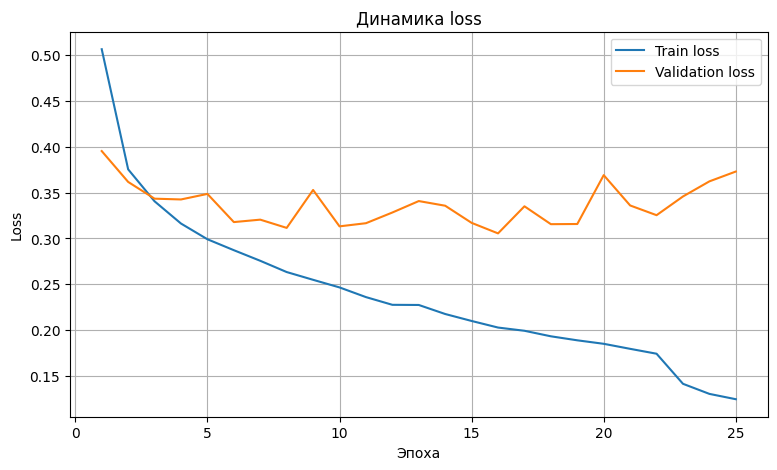

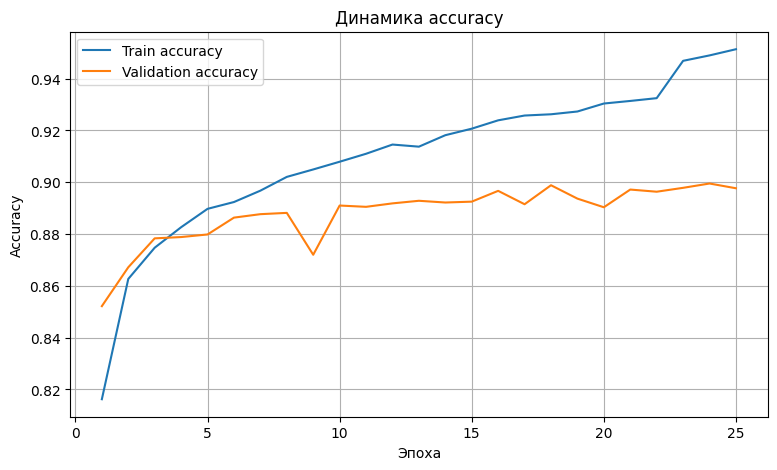

In [10]:
epochs = range(1, len(history['train_loss']) + 1)

plt.figure(figsize=(9, 5))
plt.plot(epochs, history['train_loss'], label='Train loss')
plt.plot(epochs, history['validation_loss'], label='Validation loss')
plt.title('Динамика loss')
plt.xlabel('Эпоха')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

plt.figure(figsize=(9, 5))
plt.plot(epochs, history['train_accuracy'], label='Train accuracy')
plt.plot(epochs, history['validation_accuracy'], label='Validation accuracy')
plt.title('Динамика accuracy')
plt.xlabel('Эпоха')
plt.ylabel('Accuracy')
plt.legend()
plt.grid(True)
plt.show()

## 7. Итоговая оценка

Загрузим веса модели, показавшей лучшую accuracy на validation, и только после этого оценим качество на тестовой выборке.

In [11]:
model.load_state_dict(torch.load(best_model_path, map_location=device))
model.to(device)

test_loss, test_accuracy = evaluate(model, test_loader, criterion, device)

print(f'Test loss: {test_loss:.4f}')
print(f'Test accuracy: {test_accuracy:.2%}')

assert test_accuracy > 0.88, (
    f'Точность {test_accuracy:.2%} ниже требуемого порога 88%'
)

Test loss: 0.3586
Test accuracy: 90.18%


## 8. Анализ результатов

В работе использовалась многослойная полносвязная нейронная сеть для классификации изображений Fashion MNIST. Архитектура: входной вектор из 784 признаков, три скрытых полносвязных слоя на 1024, 512 и 256 нейронов, затем выходной слой на 10 классов.

Всего в модели четыре полносвязных слоя: три скрытых слоя и один выходной слой. В скрытых слоях использовалась функция активации `ReLU`. Для регуляризации применялись `Dropout` и `weight_decay` в оптимизаторе `AdamW`. Итоговая тестовая точность выводится в предыдущей ячейке как `Test accuracy`; автоматическая проверка `assert test_accuracy > 0.88` подтверждает выполнение условия задания.

Нормализация помогает привести значения пикселей к более удобному масштабу, из-за чего обучение становится стабильнее. `Dropout` снижает переобучение, потому что во время обучения случайно отключает часть нейронов и не дает модели слишком сильно опираться на отдельные признаки. Изменение количества нейронов влияет на емкость модели: слишком маленькая сеть может недообучаться, а слишком большая без регуляризации может переобучаться.

In [9]:
print('Финальная архитектура модели:')
print(model)
print(f'Общее количество обучаемых параметров: {count_trainable_parameters(model):,}'.replace(',', ' '))
print(f'Итоговая test accuracy: {test_accuracy:.2%}')
print(f'Условие accuracy > 88% выполнено: {test_accuracy > 0.88}')

Финальная архитектура модели:
FashionMNISTMLP(
  (network): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=1024, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=1024, out_features=512, bias=True)
    (5): ReLU()
    (6): Dropout(p=0.2, inplace=False)
    (7): Linear(in_features=512, out_features=256, bias=True)
    (8): ReLU()
    (9): Dropout(p=0.1, inplace=False)
    (10): Linear(in_features=256, out_features=10, bias=True)
  )
)
Общее количество обучаемых параметров: 1 462 538
Итоговая test accuracy: 90.18%
Условие accuracy > 88% выполнено: True
